### Section 1 — Dataset Metadata & Research Context

#### 1.1 Introduction
 Objective

- Before developing any preprocessing pipeline or deep learning model, it is essential to thoroughly understand the dataset itself. Every engineering decision in this project should be supported by evidence obtained from systematic data investigation rather than assumptions.

- The objective of this notebook is to investigate the Magnetic Tile Surface Defect Dataset from a statistical, engineering, and practical perspective. Rather than simply visualizing the data, we aim to identify characteristics that may influence model design, preprocessing strategies, evaluation methodology, and deployment considerations.

- The findings of this notebook will serve as the foundation for all subsequent stages of the project.

In [19]:
# imports
from pathlib import Path
import hashlib
from scipy.stats import chisquare
import pandas as pd
from collections import defaultdict
from PIL import Image
import random
import matplotlib.pyplot as plt


#### Research Question (RQ-01)

`Does the physical organization of the dataset accurately represent its logical organization, and can it support a reliable computer vision pipeline?`
- Why is this question important?

- Before analyzing image statistics or training deep learning models, we must verify that the dataset organization itself is logically consistent.

- An incorrectly organized dataset can introduce subtle bugs into data loading, label assignment, image-mask pairing, and evaluation. Such issues often remain undetected until much later in the development process, making them expensive to diagnose and correct.

- Therefore, our first investigation focuses on understanding how the dataset is structured rather than what the images contain.

`Expected Evidence`

By the end of this investigation we expect to answer:

- How are classes represented?
- How is a sample uniquely identified?
- How are masks associated with images?
- Does folder organization introduce hidden assumptions?
- Can our future Dataset class rely entirely on folder structure?

In [2]:
# ---------------------------------------------------------------------
# Dataset Root
# ---------------------------------------------------------------------

DATASET_ROOT = Path("../data/raw/magnetic_tile")

# ---------------------------------------------------------------------
# Class Directories
# ---------------------------------------------------------------------

class_directories = sorted(
    [
        directory
        for directory in DATASET_ROOT.iterdir()
        if directory.is_dir()
    ]
)

print("=" * 70)
print("DATASET STRUCTURE")
print("=" * 70)

for class_dir in class_directories:

    print(f"\n📁 {class_dir.name}")

    imgs_dir = class_dir / "Imgs"

    if imgs_dir.exists():

        jpg_count = len(list(imgs_dir.glob("*.jpg")))
        png_count = len(list(imgs_dir.glob("*.png")))

        print(f"    Images (.jpg): {jpg_count}")
        print(f"    Masks  (.png): {png_count}")

DATASET STRUCTURE

📁 MT_Blowhole
    Images (.jpg): 115
    Masks  (.png): 115

📁 MT_Break
    Images (.jpg): 85
    Masks  (.png): 85

📁 MT_Crack
    Images (.jpg): 57
    Masks  (.png): 57

📁 MT_Fray
    Images (.jpg): 32
    Masks  (.png): 32

📁 MT_Free
    Images (.jpg): 952
    Masks  (.png): 952

📁 MT_Uneven
    Images (.jpg): 103
    Masks  (.png): 103


#### Observations: 
`O-001 — Dataset Organization`

The dataset is organized into six separate class directories, with each directory representing one defect category.

Each class directory contains an Imgs folder, which stores both the original grayscale inspection images (.jpg) and their corresponding segmentation masks (.png).

`O-002 — One-to-One Image–Mask Correspondence`

For every class:

Number of JPG files = Number of PNG files

This indicates a one-to-one correspondence between original inspection images and segmentation masks.

At this stage, this is an observation based on file counts. We already verified exact image–mask pairing and integrity in the dataset audit, so this notebook interprets what that organization means rather than re-validating it.

`O-003 — Annotation Organization`

The dataset stores annotations alongside the original images rather than in a separate annotation directory.

Therefore,

annotation retrieval is deterministic,
pairing does not require an external annotation file,
filenames become the unique sample identifiers.

`O-004 — Label Encoding Strategy`

Class labels are not stored inside filenames.

Instead,

the directory name represents the class label.

**This dataset is more valuable than a standard image classification dataset because every sample provides three complementary sources of information:**

#### Class Label
- Enables image classification.
- Pixel-Level Segmentation Mask
- Enables semantic segmentation.
- Enables geometric analysis of defects.
- Original Grayscale Inspection Image
- Enables statistical image analysis, feature extraction, and texture analysis.

This means the dataset can potentially support:

#### Classification
- Segmentation
- Defect localization
- Severity estimation (derived from masks)
- Explainability validation

without requiring additional annotations.

#### Research Question (RQ-02)

Does the dataset contain exact duplicate images that could bias model training or evaluation?

**Exact Duplication Check**

In [3]:
# ----------------------------------------------------------
# Collect all original images
# ----------------------------------------------------------

DATASET_ROOT = Path("../data/raw/magnetic_tile")

image_paths = sorted(DATASET_ROOT.rglob("*.jpg"))

# ----------------------------------------------------------
# Compute MD5 hashes
# ----------------------------------------------------------

hash_to_files = defaultdict(list)

for image_path in image_paths:

    with open(image_path, "rb") as f:
        file_hash = hashlib.md5(f.read()).hexdigest()

    hash_to_files[file_hash].append(image_path)

# ----------------------------------------------------------
# Find duplicate groups
# ----------------------------------------------------------

duplicate_groups = [
    files
    for files in hash_to_files.values()
    if len(files) > 1
]

print("=" * 70)
print("EXACT DUPLICATE ANALYSIS")
print("=" * 70)

print(f"Total Images           : {len(image_paths)}")
print(f"Duplicate Groups       : {len(duplicate_groups)}")

duplicate_images = sum(len(group) for group in duplicate_groups)

print(f"Duplicate Images       : {duplicate_images}")

if duplicate_groups:

    print("\nDuplicate Groups\n")

    for i, group in enumerate(duplicate_groups, start=1):

        print(f"Group {i}")

        for file in group:
            print(f"   {file}")

        print()

EXACT DUPLICATE ANALYSIS
Total Images           : 1344
Duplicate Groups       : 0
Duplicate Images       : 0


Why MD5?

- For this investigation, MD5 is appropriate because we are checking exact binary equality, not cryptographic security. Two files with the same MD5 hash are overwhelmingly likely to be byte-for-byte identical, which is exactly the property we want to test.

- This concludes that there are no Exact duplicate images.

### Research Question (RQ-03)

How severe is the class imbalance, and what are its statistical and engineering implications for model development?

**Motivation**

- Class distribution is one of the most influential characteristics of any supervised learning dataset.

- An imbalanced dataset can bias a model toward majority classes, reduce minority-class recall, distort evaluation metrics, and affect confidence calibration.

- Understanding the degree and nature of class imbalance is therefore essential before selecting data splitting strategies, loss functions, augmentation policies, and evaluation metrics.

`Null Hypothesis (H₀)`

- The observed class frequencies do not differ significantly from a uniform class distribution.

`Alternative Hypothesis (H₁)`

- The observed class frequencies differ significantly from a uniform class distribution.

In [5]:
# --------------------------------------------------------
# Collect class counts
# --------------------------------------------------------

DATASET_ROOT = Path("../data/raw/magnetic_tile")

class_counts = {}

for class_dir in sorted(DATASET_ROOT.iterdir()):

    if not class_dir.is_dir():
        continue

    image_count = len(list((class_dir / "Imgs").glob("*.jpg")))

    class_counts[class_dir.name] = image_count

# --------------------------------------------------------
# Create DataFrame
# --------------------------------------------------------

class_df = (
    pd.DataFrame(
        {
            "Class": class_counts.keys(),
            "Count": class_counts.values(),
        }
    )
    .sort_values("Count", ascending=False)
    .reset_index(drop=True)
)

total_samples = class_df["Count"].sum()

class_df["Percentage"] = (
    class_df["Count"] / total_samples * 100
)

print(class_df)

print("\n")

print(f"Total Samples : {total_samples}")

print(f"Number of Classes : {len(class_df)}")

         Class  Count  Percentage
0      MT_Free    952   70.833333
1  MT_Blowhole    115    8.556548
2    MT_Uneven    103    7.663690
3     MT_Break     85    6.324405
4     MT_Crack     57    4.241071
5      MT_Fray     32    2.380952


Total Samples : 1344
Number of Classes : 6


**Initial Observations**

What we can objectively observe :

`O-007.1`

- One class (MT_Free) alone represents 70.83% of the entire dataset.

- This immediately suggests that the dataset is dominated by defect-free samples.

`O-007.2`

- The remaining five defect classes collectively account for only 29.17% of all observations.

- This means the dataset is not only imbalanced, but also heavily skewed toward the "no defect" condition.

`O-007.3`

- The smallest class (MT_Fray) contributes only 2.38% of the dataset.

- Such limited representation may reduce the model's ability to learn discriminative features for this defect type.

`O-007.4`

- The defect classes themselves are not uniformly distributed.

- Even after excluding MT_Free, substantial differences remain among the defective categories.

**Preliminary Interpretation**

- At this stage we cannot yet conclude that the imbalance is statistically significant.

`We have only established that:`

- the majority class dominates the dataset,
- minority classes are substantially underrepresented,
- defect classes are themselves unevenly represented.

Whether this imbalance is statistically significant will be tested formally in the next section.

`Possible Risk 1`

- A model trained with standard cross-entropy loss may become biased toward predicting the majority class.

`Possible Risk 2`

- Overall accuracy may become misleading because a classifier can achieve high accuracy by correctly predicting the dominant class while performing poorly on rare defects.

`Possible Risk 3`

**Minority classes may require additional support through:**

- weighted loss functions,
- targeted augmentation,
- balanced sampling,
- specialized evaluation metrics.

These are hypotheses, not conclusions. They require further evidence.

**Research Question (RQ-03.1)**

- Is the observed class distribution significantly different from a uniform distribution?

We select the `Chi-Square Goodness-of-Fit Test` because:

- The response variable (class label) is categorical.
- We have observed frequencies.
- We want to compare them against an expected theoretical distribution (uniform).
- Expected counts satisfy the assumptions of the test.

In [7]:


# ---------------------------------------------------------
# Observed Frequencies
# ---------------------------------------------------------

observed = class_df["Count"].to_numpy()

# ---------------------------------------------------------
# Expected Frequencies (Uniform Distribution)
# ---------------------------------------------------------

expected = [observed.sum() / len(observed)] * len(observed)

# ---------------------------------------------------------
# Chi-Square Goodness-of-Fit Test
# ---------------------------------------------------------

chi2_statistic, p_value = chisquare(
    f_obs=observed,
    f_exp=expected
)

# ---------------------------------------------------------
# Results
# ---------------------------------------------------------

results = pd.DataFrame(
    {
        "Observed": observed,
        "Expected": expected
    },
    index=class_df["Class"]
)

display(results)

print(f"\nChi-Square Statistic : {chi2_statistic:.4f}")
print(f"P-value              : {p_value:.10f}")

,Observed,Expected
Class,,
MT_Free,952,224.0
MT_Blowhole,115,224.0
MT_Uneven,103,224.0
MT_Break,85,224.0
MT_Crack,57,224.0
MT_Fray,32,224.0



Chi-Square Statistic : 2859.7321
P-value              : 0.0000000000


Since p-value << 0.05, we reject the null hypothesis.
There is overwhelming statistical evidence that the observed class frequencies do not follow a uniform distribution.

---

#### Research Question- (RQ 05)
>
> Are the defect classes visually distinguishable, and what characteristics differentiate them?

---

#### Motivation

Before performing quantitative image analysis, it is important to visually inspect representative samples from each class. Human observations can reveal defect characteristics, annotation quality, potential ambiguities, and engineering challenges that are not immediately apparent from summary statistics.

---

#### Method

Random samples from each defect class are visualized along with their corresponding segmentation masks. Visual inspection is performed to identify common patterns, differences between classes, and potential challenges for automated defect recognition.

---

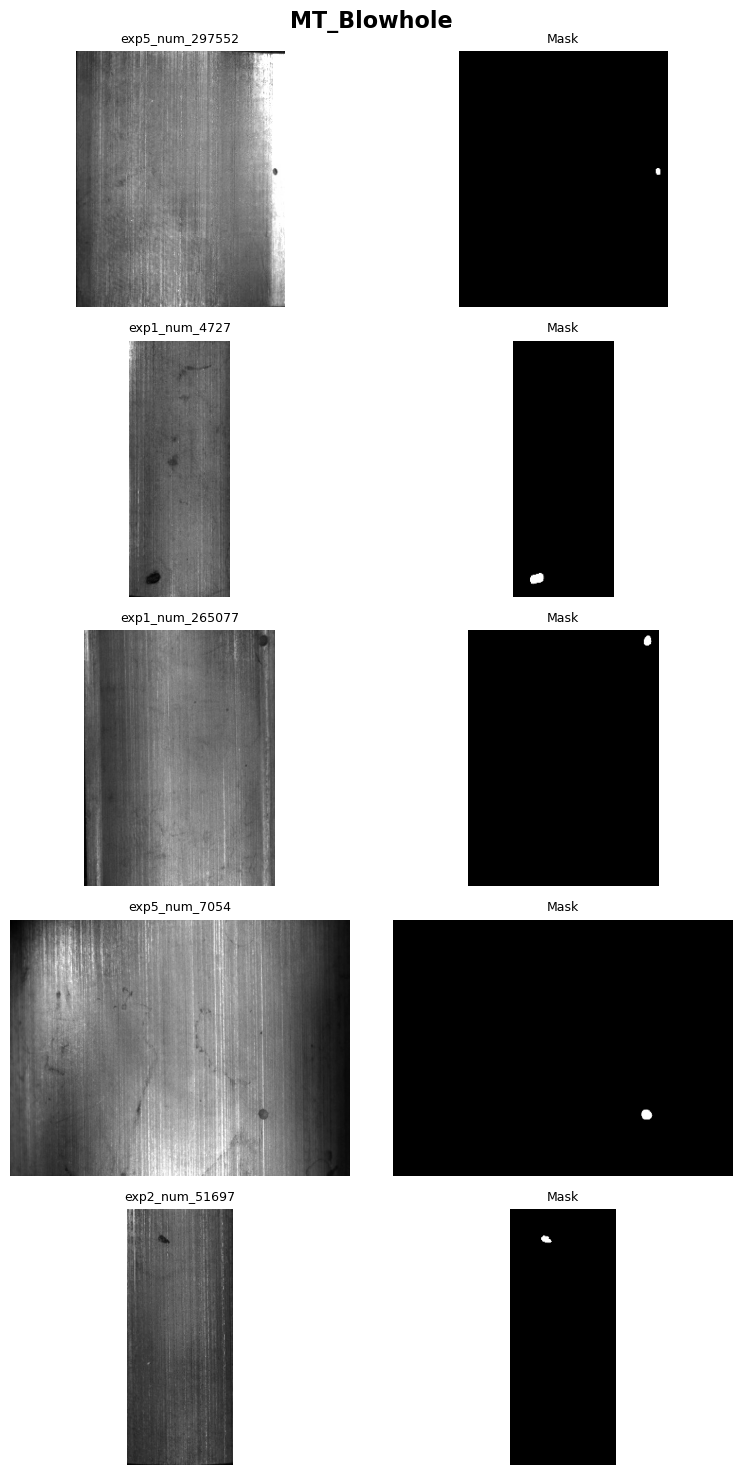

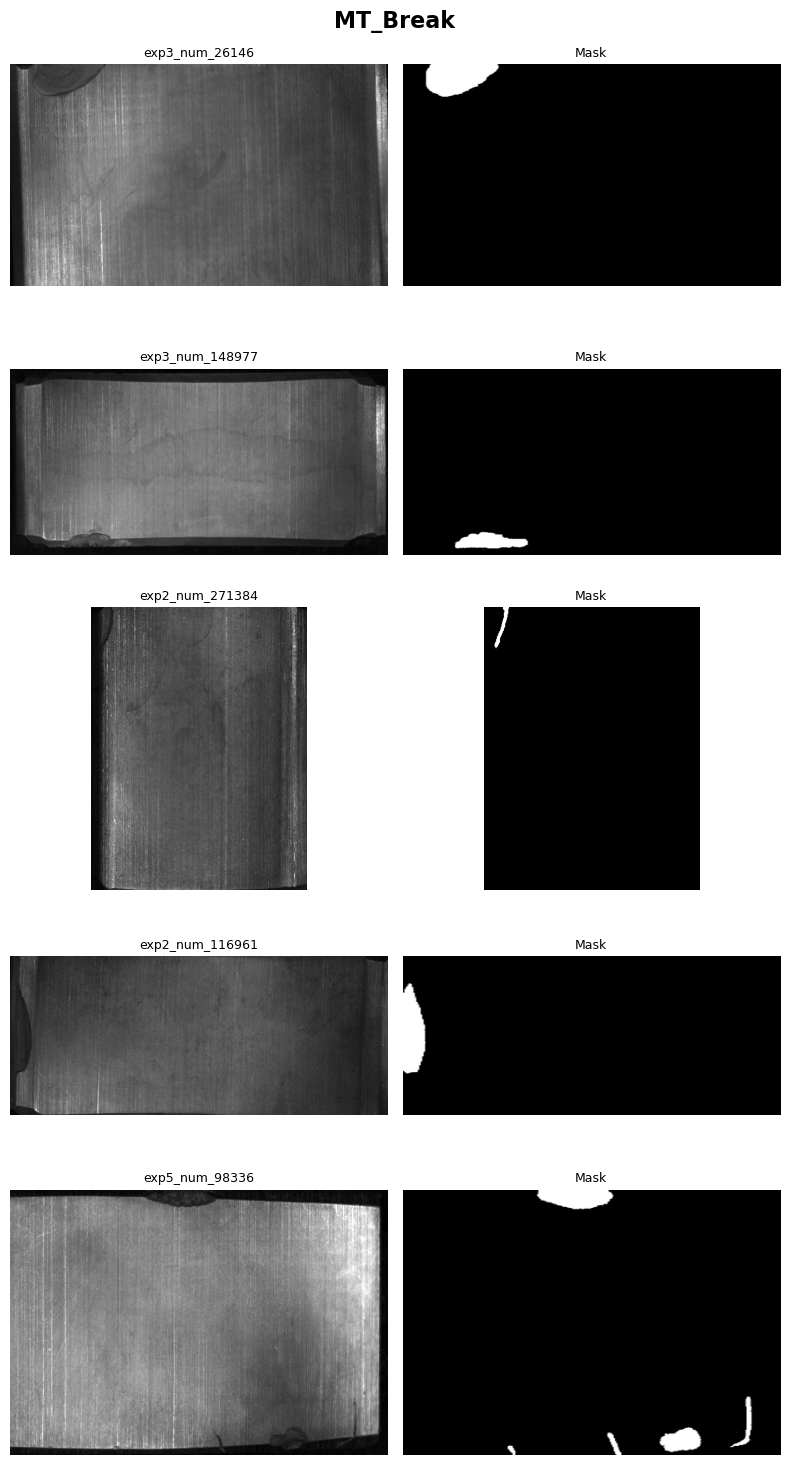

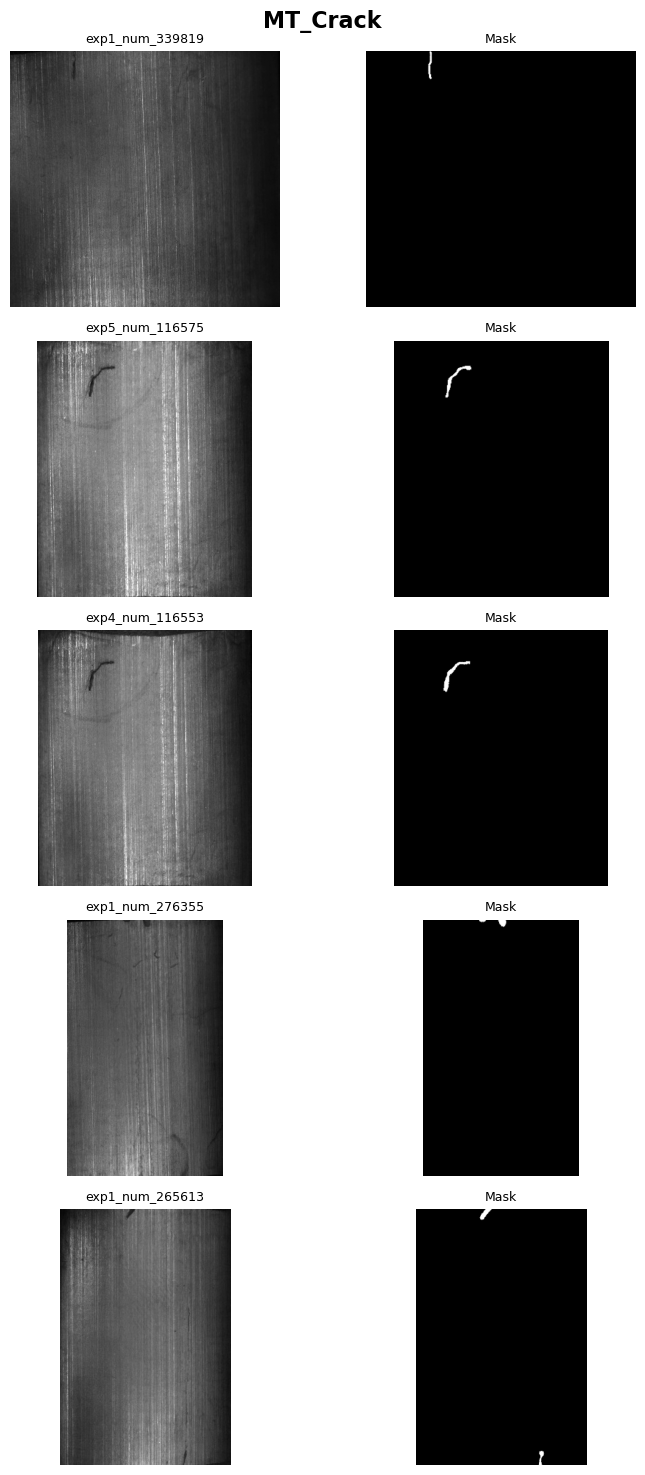

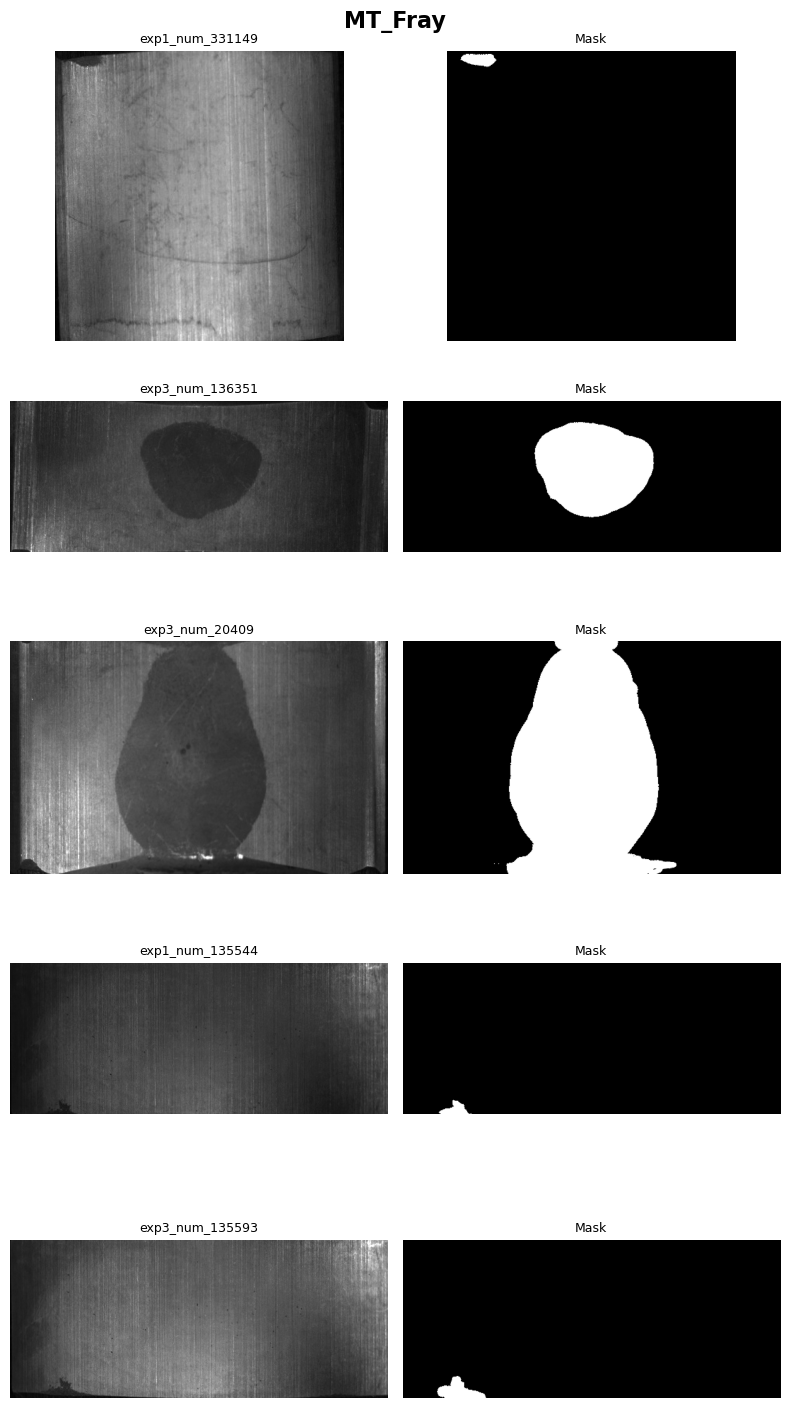

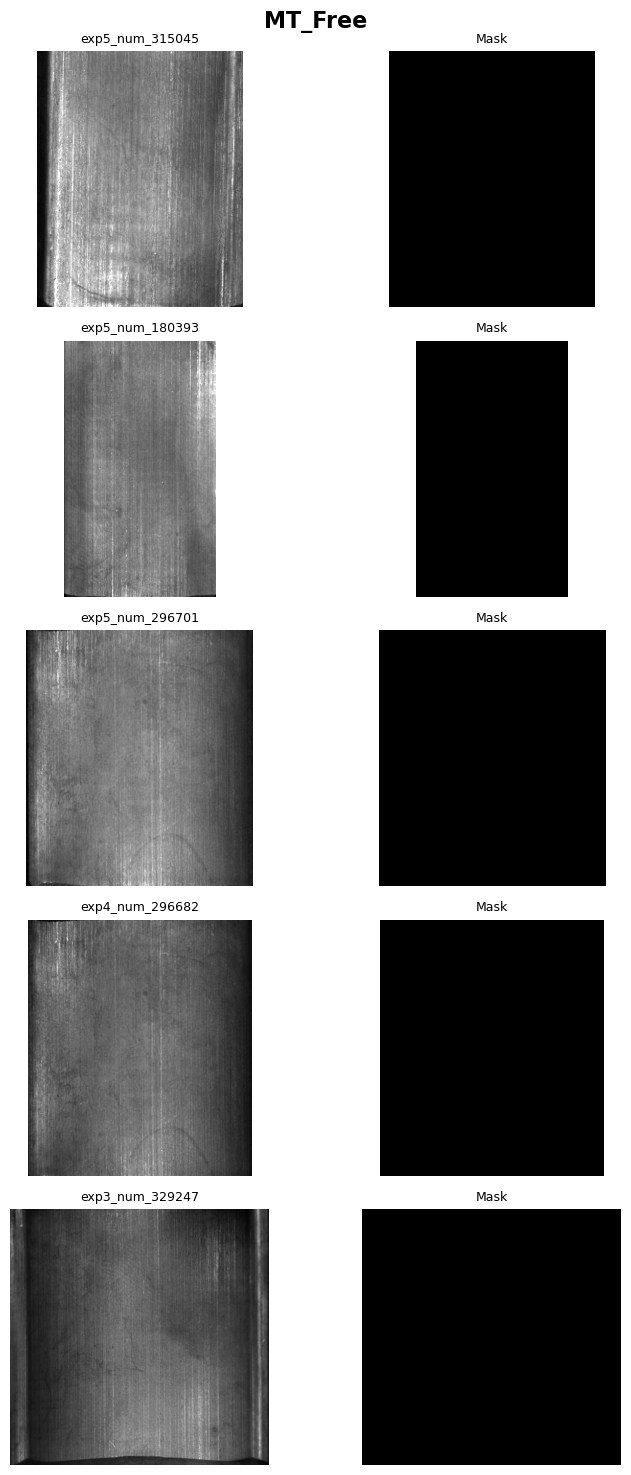

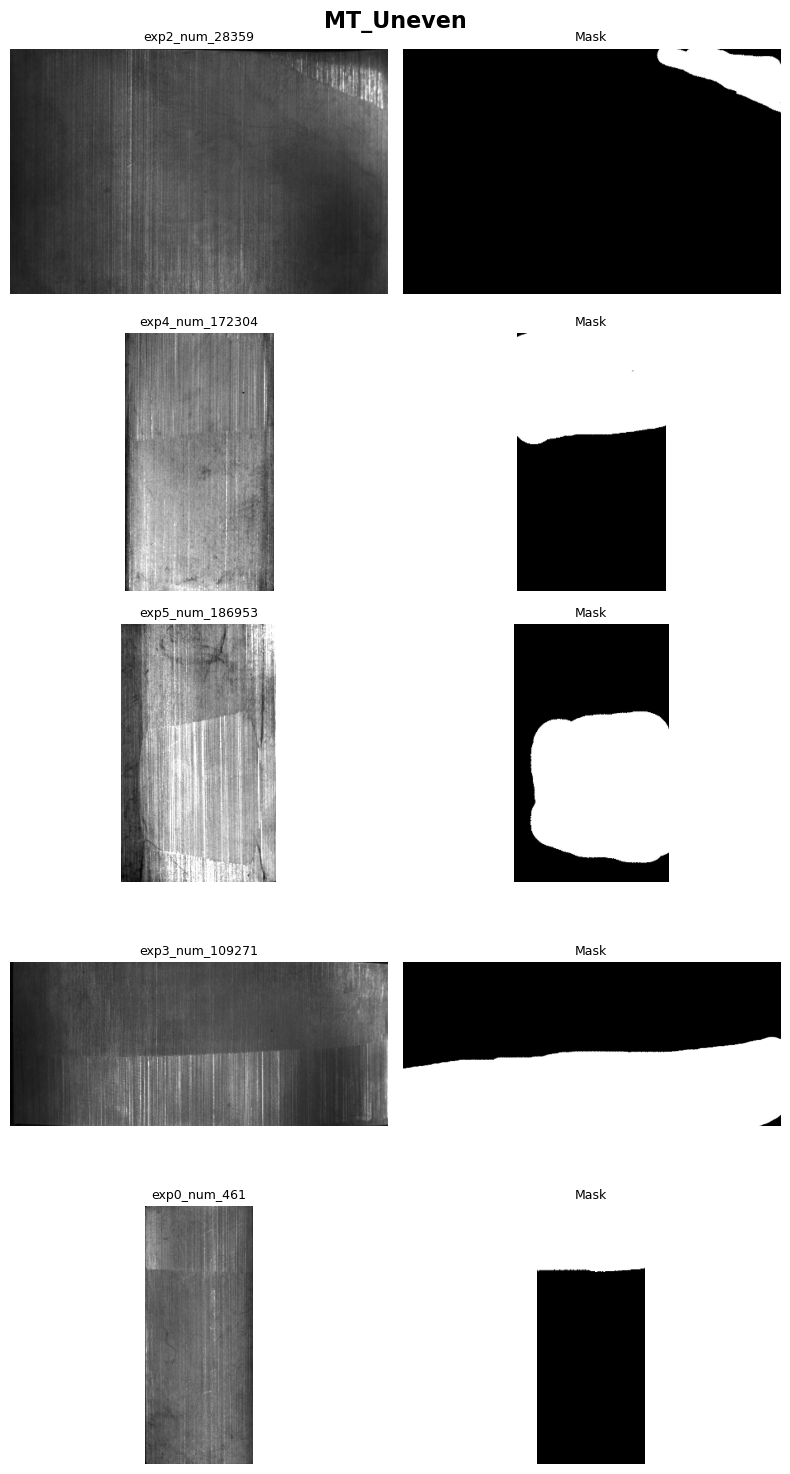

In [21]:
# ---------------------------------------------------------
# Configuration
# ---------------------------------------------------------

DATASET_ROOT = Path("../data/raw/magnetic_tile")

SAMPLES_PER_CLASS = 5

random.seed(42)

# ---------------------------------------------------------
# Visualize Samples
# ---------------------------------------------------------

for class_dir in sorted(DATASET_ROOT.iterdir()):

    if not class_dir.is_dir():
        continue

    image_dir = class_dir / "Imgs"

    image_paths = sorted(image_dir.glob("*.jpg"))

    selected_images = random.sample(image_paths, SAMPLES_PER_CLASS)

    fig, axes = plt.subplots(
        SAMPLES_PER_CLASS,
        2,
        figsize=(8, 3 * SAMPLES_PER_CLASS)
    )

    fig.suptitle(
        class_dir.name,
        fontsize=16,
        fontweight="bold"
    )

    for row, image_path in enumerate(selected_images):

        mask_path = image_path.with_suffix(".png")

        image = Image.open(image_path)
        mask = Image.open(mask_path)

        axes[row, 0].imshow(image, cmap="gray")
        axes[row, 0].set_title(image_path.stem, fontsize=9)
        axes[row, 0].axis("off")

        axes[row, 1].imshow(mask, cmap="gray")
        axes[row, 1].set_title("Mask", fontsize=9)
        axes[row, 1].axis("off")

    plt.tight_layout()

    plt.show()

### Class: MT_Free

#### Observations

- Images do not exhibit any obvious surface defects such as cracks, blowholes, frays, or uneven regions.
- Segmentation masks are completely black, indicating the absence of annotated defects.
- The tile surface contains natural manufacturing textures (vertical streaks and intensity variations) that are present across multiple samples.
- Illumination is not perfectly uniform; noticeable brightness gradients exist between images.
- Minor scratches and texture variations are visible but are not annotated as defects.

---

#### Interpretation

MT_Free represents defect-free magnetic tiles. Although no defects are present, normal surface texture and illumination variations introduce natural intra-class variability that the model must learn to distinguish from true defects.

---

#### Engineering Insight

- Normal surface texture should not be interpreted as a defect.
- Preprocessing should preserve fine surface details while reducing illumination variation where appropriate.
- The completely empty masks confirm that this class represents genuine negative samples.

### Class: MT_Blowhole

#### Observations

- Blowholes appear as small, localized dark spots on the tile surface.
- Most defects occupy only a very small fraction of the image area.
- Segmentation masks accurately isolate the blowhole while excluding the surrounding background.
- Defects occur at different spatial locations with no obvious positional pattern.
- The surrounding surface texture is similar to defect-free tiles, making the defect the primary discriminative feature.

---

#### Interpretation

Blowholes are compact, isolated defects with good annotation quality. Their small size suggests that detecting fine local features will be more important than learning global image characteristics.

---

#### Engineering Insight

- High-resolution spatial information should be preserved during preprocessing.
- Excessive downsampling may remove or weaken small blowhole features.
- Data augmentation should preserve small defect structures and avoid transformations that distort them.

## Class: MT_Break

### Observations

- Defects are generally large and irregular, frequently located near image boundaries.
- Defect regions occupy a significantly larger area than blowholes or cracks.
- Segmentation masks closely follow the damaged regions with good annotation quality.
- Boundary defects may be partially visible due to image cropping.

---

### Interpretation

Break defects are large structural failures that are visually prominent and easy to distinguish from the background.

---

### Engineering Insight

Large defect regions are unlikely to be lost during resizing, but border-aware augmentations should be applied carefully.

---

## Class: MT_Crack

### Observations

- Cracks appear as thin, elongated, line-like structures.
- Defects occupy only a very small portion of the image.
- Segmentation masks accurately capture the crack geometry.
- Crack orientation and position vary across samples.

---

### Interpretation

Cracks are fine structural defects requiring the model to preserve high-frequency edge information.

---

### Engineering Insight

Aggressive downsampling or excessive smoothing may reduce crack visibility and negatively impact detection.

---

## Class: MT_Fray

### Observations

- Fray defects appear as large irregular damaged regions with varying shapes.
- Defect size varies considerably across samples.
- Segmentation masks accurately cover the affected regions.
- Some defects extend to image boundaries.

---

### Interpretation

Fray exhibits high intra-class variability, making it visually more diverse than other defect classes.

---

### Engineering Insight

Data augmentation should preserve defect morphology while exposing the model to diverse fray appearances.

---

## Class: MT_Uneven

### Observations

- Uneven defects appear as broad intensity variations covering large surface regions.
- Defect boundaries are relatively smooth and continuous.
- Segmentation masks consistently capture the affected surface area.
- Defects are characterized more by gradual appearance changes than sharp edges.

---

### Interpretation

Unlike localized defects, uneven defects represent large-scale surface inconsistencies that modify overall appearance.

---

### Engineering Insight

Both local texture and global contextual information will be important for reliable detection of uneven defects.

# Initial Engineering Risk Assessment

The exploratory analysis identified several dataset characteristics that may influence model development and evaluation.

| Risk | Impact | Remarks |
|------|--------|---------|
| Severe class imbalance | High | Majority class (MT_Free) dominates the dataset. |
| Small localized defects | High | Blowholes and cracks occupy very small image regions. |
| Large defect variability | Medium | Fray and Uneven exhibit considerable variation in size and shape. |
| Illumination variation | Medium | Brightness varies noticeably across images. |
| Variable image resolutions | Medium | Images are captured at multiple resolutions. |
| No duplicate images | Low | No exact duplicate samples were detected. |
| Annotation quality | Low | Visual inspection indicates consistent and accurate masks. |

---

## Key Findings

- The dataset is well-organized with complete image-mask pairing.
- No exact duplicate images were detected.
- The dataset exhibits significant class imbalance.
- Defect morphology varies considerably across classes.
- Small defects require preservation of fine spatial details during preprocessing.
- Annotation quality appears reliable based on visual inspection.

---

## Outcome

The dataset passes the initial quality assessment and is ready for detailed statistical analysis of the original grayscale images.